# Linear Regression Analysis of Altima Sales

In [13]:
import pandas as pd
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_percentage_error
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [14]:
# Load the dataset
df = pd.read_excel('Modeling dataset.xlsx', sheet_name='modeling dataset', engine='openpyxl')
df.head()

,model,month,gas_price,discount,sales,TV,YouTube,Radio,Print
0,altima,2018-04-01,2.757,2169.005767,6799,0.0,6.313814e-06,0.000000,1.398882
1,altima,2018-05-01,2.901,4745.168681,14992,0.0,6.313814e-06,3.300356,0.224208
2,altima,2018-06-01,2.891,4895.379638,19572,0.0,7.892268e-07,6.479757,0.147138
3,altima,2018-07-01,2.849,4923.842447,14876,0.0,0.000000e+00,11.619001,0.680676
4,altima,2018-08-01,2.836,5026.378048,14656,0.0,0.000000e+00,32.458100,1.633934


In [15]:
# Define the dependent variable (Sales) and independent variables
df['covid_dummy'] = df['month'].apply(lambda x: 1 if x==pd.to_datetime('2020-04-01') else 0)
df['Month index']=pd.to_datetime(df['month']).dt.month
df["Seasonality"] = df.groupby(['Month index'])["sales"].transform('mean')/df['sales'].mean()


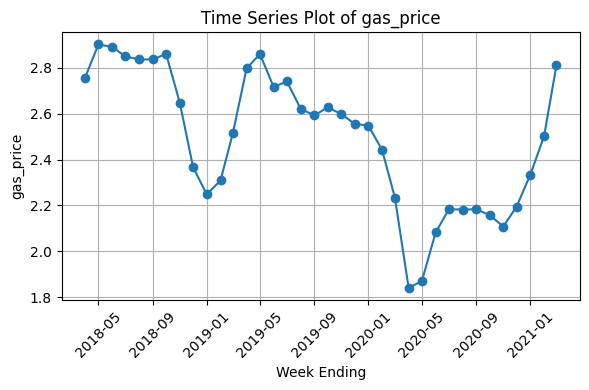

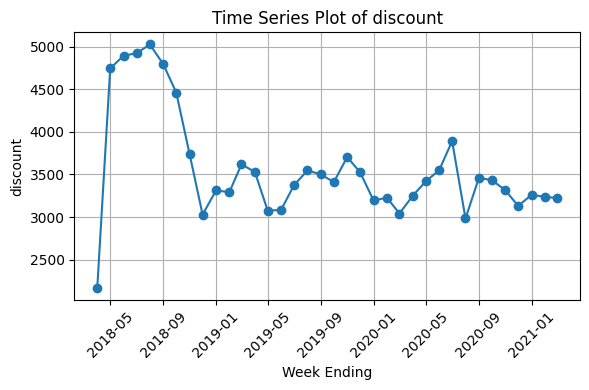

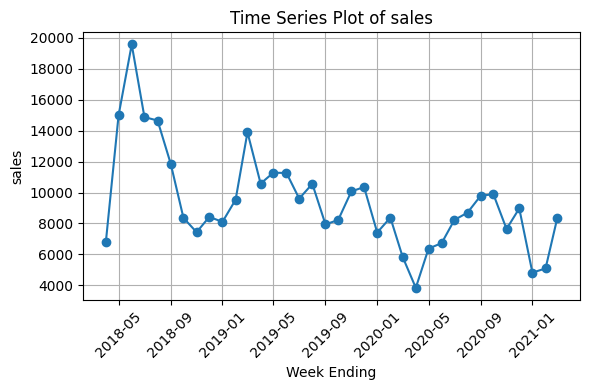

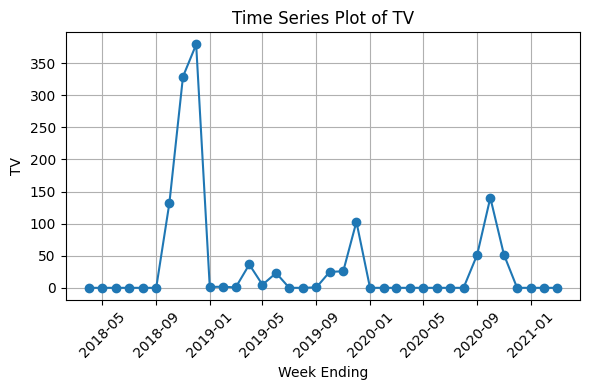

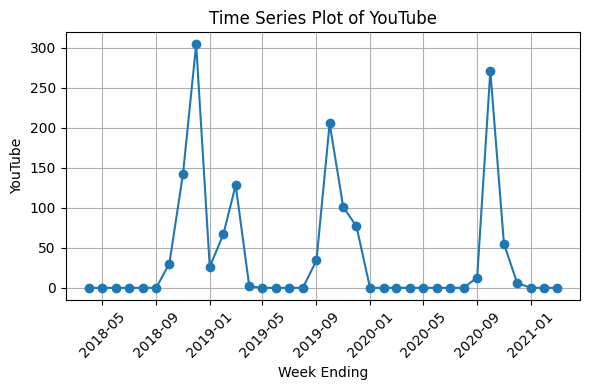

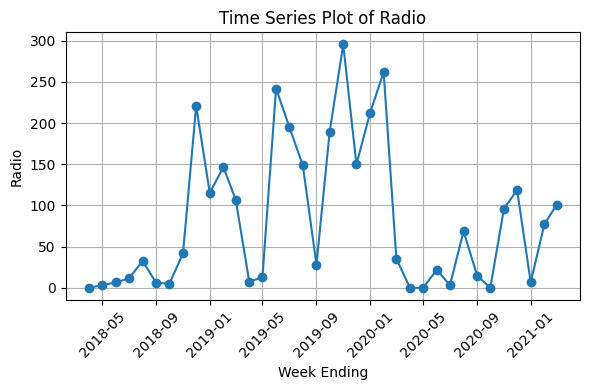

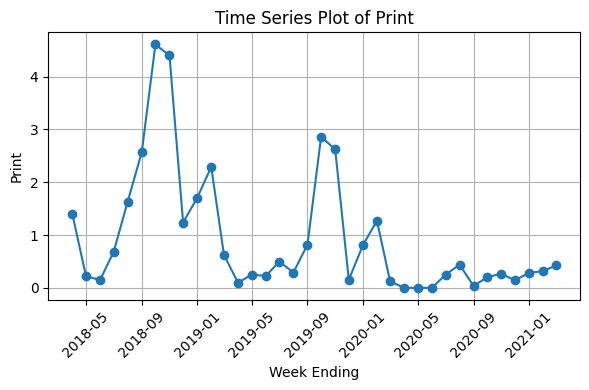

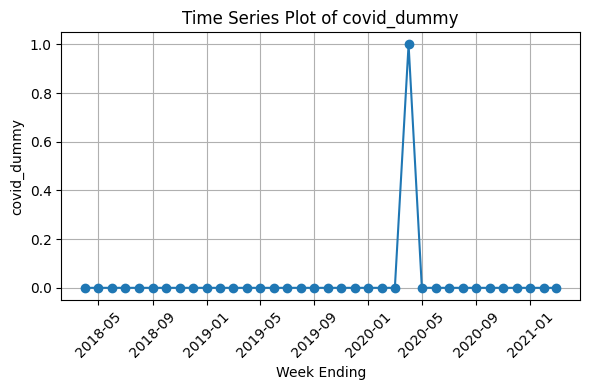

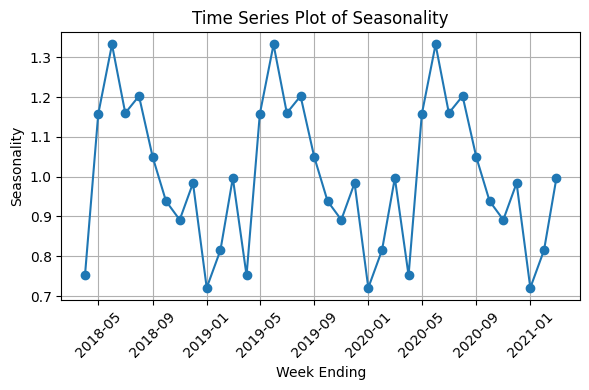

In [16]:
variables =df.columns[2:-2].to_list()+['Seasonality']
# Create time series plots for each variable
for variable in variables:
    plt.figure(figsize=(6, 4))
    plt.plot(df['month'], df[variable], marker='o')
    plt.title(f'Time Series Plot of {variable}')
    plt.xlabel('Week Ending')
    plt.ylabel(variable)
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

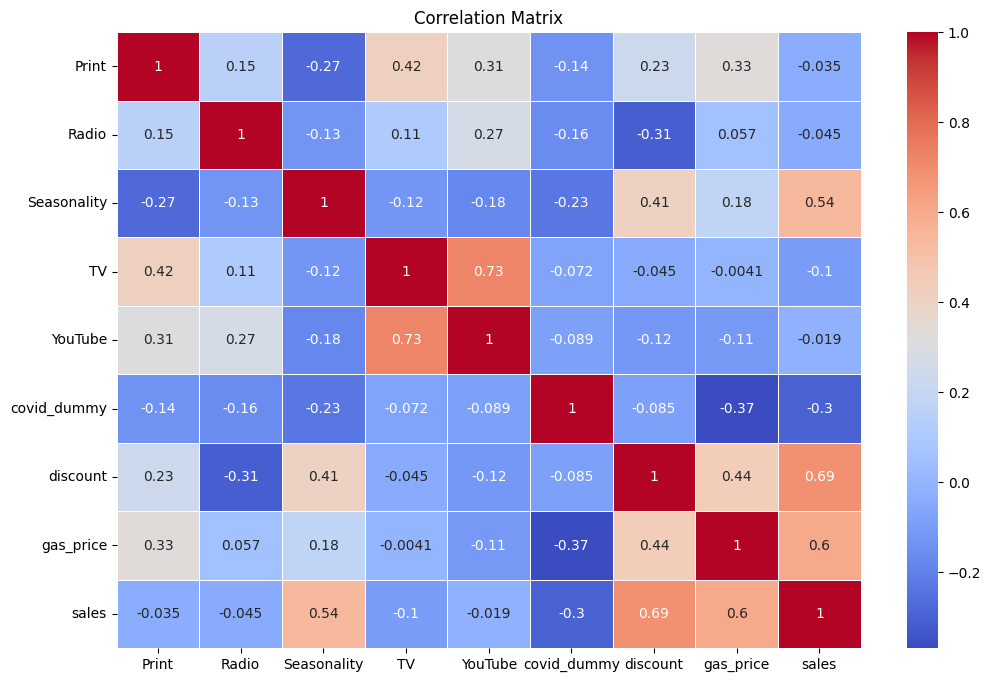

In [17]:
# Correlation matrix
correlation_matrix = df[df.columns.difference(["Month index", "model","month"])].corr()
# Plotting the correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

In [18]:
correlation_matrix['sales'].sort_values(ascending=False)

sales          1.000000
discount       0.688350
gas_price      0.601739
Seasonality    0.538990
YouTube       -0.019420
Print         -0.035276
Radio         -0.045434
TV            -0.101003
covid_dummy   -0.297982
Name: sales, dtype: float64

In [19]:
def apl_transformation(series, adstock_rate=0.5, power=0.5):
    result = []
    for i in range(len(series)):
        if i == 0:
            result.append(series[i] ** power)
        else:
            result.append((series[i] + adstock_rate * result[i - 1]) ** power)
    return result

# Define specific adstock_rate and power values for each tactic from domain knowledge
tactic_params = {
    'TV': {'adstock_rate': 0.75, 'power': 0.4},
    'YouTube': {'adstock_rate': 0.7, 'power': 0.6},
    'Radio': {'adstock_rate': 0.75, 'power': 0.6},
    'Print': {'adstock_rate': 0.8, 'power': 0.6}
}
# Apply APL transformation using the specific parameters
for column, params in tactic_params.items():
    df[column] = apl_transformation(df[column], adstock_rate=params['adstock_rate'], power=params['power'])

In [20]:
# Create 1-week and 2-week lagged versions of 'Discount'
df['discount_lag1'] = df['discount'].shift(1)
df['discount_lag2'] = df['discount'].shift(2)

# Fill NaN values with the last valid observation
df.loc[0, 'discount_lag1'] = df.loc[1, 'discount_lag1']
df.loc[0:1, 'discount_lag2'] = df.loc[2, 'discount_lag2']

# Compute the correlation with 'Sales'
correlation_matrix = df[['sales','discount','discount_lag1', 'discount_lag2']].corr()['sales']

# Print the correlation matrix
print("Correlation matrix:")
print(correlation_matrix)

Correlation matrix:
sales            1.000000
discount         0.688350
discount_lag1    0.401988
discount_lag2    0.004001
Name: sales, dtype: float64


In [21]:
df['gas_price_1'] = df['gas_price'].shift(1)
df.loc[0, 'gas_price_1'] = df.loc[1, 'gas_price_1']

# Compute the correlation with 'sales'
print(df[['sales','gas_price','gas_price_1']].corr()['sales'])

sales          1.000000
gas_price      0.601739
gas_price_1    0.522104
Name: sales, dtype: float64


In [22]:
X = df[['covid_dummy','gas_price', 'discount', 'TV', 'YouTube', 'Radio', 'Print',"Seasonality"]]
y = df['sales']
X = sm.add_constant(X)

In [23]:
# Fit the linear regression model
model = sm.OLS(y, X).fit()
model_summary = model.summary()
print(model_summary)

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.771
Model:                            OLS   Adj. R-squared:                  0.703
Method:                 Least Squares   F-statistic:                     11.36
Date:                Sun, 27 Jul 2025   Prob (F-statistic):           6.87e-07
Time:                        14:09:00   Log-Likelihood:                -314.61
No. Observations:                  36   AIC:                             647.2
Df Residuals:                      27   BIC:                             661.5
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const       -1.483e+04   3286.698     -4.512      

In [24]:
# Calculate R-squared and Adjusted R-squared
r_squared = model.rsquared
adj_r_squared = model.rsquared_adj
r_squared, adj_r_squared

(0.7710005864528007, 0.7031489083647416)

In [25]:
# Calculate VIF to check for multicollinearity
vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i).round(2) for i in range(X.shape[1])]
vif_data.sort_values('VIF', ascending=False)

,feature,VIF
0,const,127.82
5,YouTube,3.02
4,TV,2.75
7,Print,2.44
3,discount,2.16
8,Seasonality,1.77
2,gas_price,1.70
6,Radio,1.49
1,covid_dummy,1.32


In [26]:
# Calculate MAPE
y_pred = model.predict(X)
mape = mean_absolute_percentage_error(y, y_pred)
mape

0.13871405979269627

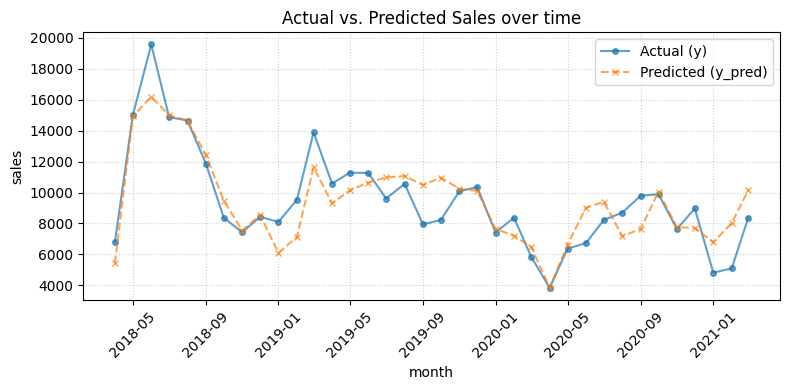

In [27]:
plt.figure(figsize=(8, 4))
# Plot actual values
plt.plot(df["month"], y, label='Actual (y)', marker='o', linestyle='-', markersize=4, alpha=0.7)
# Plot predicted values
plt.plot(df["month"], y_pred, label='Predicted (y_pred)', marker='x', linestyle='--', markersize=4, alpha=0.7)
plt.xlabel("month")
plt.ylabel("sales")
plt.title("Actual vs. Predicted Sales over time")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

# Improve x-axis date formatting
plt.xticks(rotation=45)
plt.tight_layout() # Adjusts plot to prevent labels from overlapping
plt.show()